**The notebook converts sections and corresponding bounded region to normal edge/regiona masks**
- Three parts/methods are included, depending on the sources of pre-defined *sections*
1. Sections are defined by using `/home/m/m301254/Download/pyicon/tools/tool_icon_section_transport_mask_*.py`
    - **1.1** and **1.2** focus on this method. But the mask is not perfect, especially on the boundary, where it has few missing/extra cells
2. Sections are defined by using `/home/m/m301254/proj_surfwaves/scripts/make_sections_and_bounded_region.ipynb`
    - This method uses module `iconspy`; 
    - It provides the edge/cell index for both the edges and the bounded region. Which can be used to convert to normal edge/regional masks. Corresponding process are summarised in **2.1**
3. The wrap up to save desired data structure into netcdf file is shown in **3.1**


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
import scipy.spatial as spatial
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyicon as pyic
import shapely as shp
import shapely.geometry as shpg

import os


----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


# Paths: tgrid, ckdt (r2b7 oce, r2b5 atm)

In [2]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

# 1.1 Compare: regional mask to the section edges

In [49]:
# read ocean mask file
masks = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce_2d.nc")
ds_sec_pc_all = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/section_mask_r2b7_oce_r0005_pc_all_v4.nc")

In [50]:
sections = ds_sec_pc_all

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


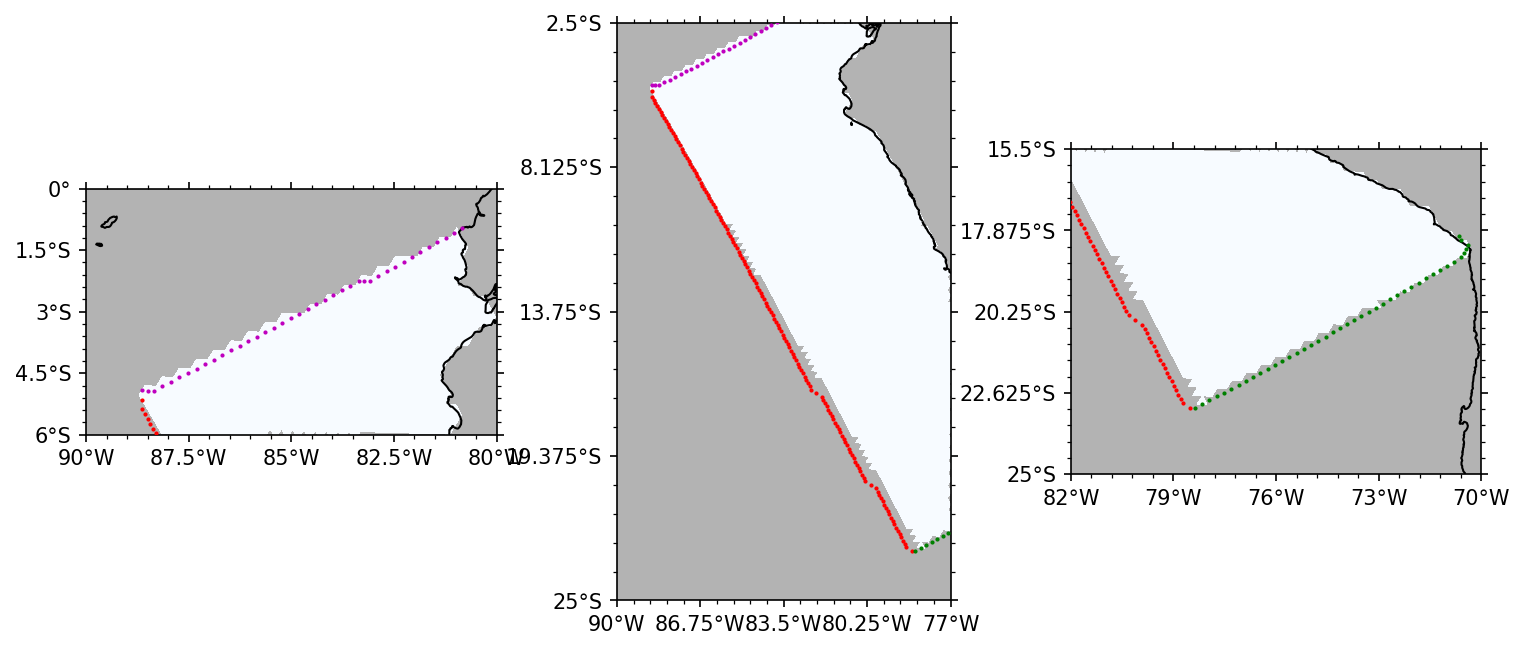

In [7]:
# plot to check if the sections are matching with the previous made mask
fig, axes = plt.subplots(1,3 ,figsize=(12,5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
axes.flatten()
mask = masks["pc_all"]

ax0, hm = mask.pyic.plot(
    ax=axes[0], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-90, -80],
    lat_reg=[-6, 0],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax1, hm = mask.pyic.plot(
    ax=axes[1], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-90, -77],
    lat_reg=[-25, -2.5],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax2, hm = mask.pyic.plot(
    ax=axes[2], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-82, -70],
    lat_reg=[-25, -15.5],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

for ax in axes:
    ax.scatter(
        sections.elon[sections.mask_pc_all_north_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_north_boundary.compute() !=0],
        c='m', s=1, zorder=3)
    ax.scatter(
        sections.elon[sections.mask_pc_all_west_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_west_boundary.compute() !=0],
        c='r', s=1, zorder=4)
    ax.scatter(
        sections.elon[sections.mask_pc_all_south_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_south_boundary.compute() !=0],
        c='g', s=1, zorder=5)
    ax.scatter(
        sections.elon[sections.mask_pc_all_east_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_east_boundary.compute() !=0],
        c='g', s=1, zorder=5)
    # ax.scatter(-78.95, -23.100, c='b', s=5, zorder=2)

# plt.savefig('/home/m/m301254/project_surfwaves/figs/peruvian_coast_masks/mask_vs_sections_r2b7.png', dpi=150, bbox_inches="tight")
plt.show()


- It is clearly mismatched. This will cause problem when close some budget of the region
- Thus, it is better to re-define the mask by using the sections (as the sections are needed to calculate the transport into/out of the region)

# 1.2 Make section polygon mask

## Function: Build mask with polygon defined by given section masks

In [4]:
from shapely import geometry as geom

def make_section_polygon_mask(ds_sec, 
                              section_list=None,
                              lat_min=60.1, lat_max=66.1,
                              lon_min=-44., lon_max=-37., add_poly=True, extra_points=None):
    """
    Build a total mask combining (a) polygon defined by given section masks and
    (b) a rectangular area, using OR logic between both.

    Parameters
    ----------
    ds_sec : xarray.Dataset
        Section dataset with mask_* variables and coordinates elon, elat.
    section_list : list of str, optional
        List of section mask suffixes to include in the polygon.
        Example: ["osnap_irminger", "osnap_iceland", "denmark_strait", 
                  "iceland_faroe_channel", "faroe_scotland_channel"]
    lat_min, lat_max : float
        Latitude bounds for rectangular area.
    lon_min, lon_max : float
        Longitude bounds for rectangular area.
    add_poly: bool
        Switch to add or not the rectangular area

    Returns
    -------
    total_mask : xarray.DataArray
        Boolean mask (dims = 'edge'), True where inside polygon OR in rectangle.
    """

    if section_list is None:
        section_list = [
            "pc_all_north_boundary",
            "pc_all_west_boundary",
            "pc_all_south_boundary",
            "pc_all_east_boundary",
        ]

    # 1 Combine all section masks (OR logic)
    mask_total = sum([ds_sec[f"mask_{sec}"] for sec in section_list])
    mask_total = (mask_total > 0)

    # 2 Get coordinates of edges in the combined mask
    lons = ds_sec.elon.where(mask_total, drop=True).values
    lats = ds_sec.elat.where(mask_total, drop=True).values

    # 3 Build convex hull polygon around the section edges
    points = list(zip(lons, lats))

    # --- append EXTRA USER-DEFINED POINTS to hull ---
    if extra_points is not None:
        for lat, lon in extra_points:
            points.append((lon, lat))   # convert to (lon, lat)

    poly = geom.MultiPoint(points).convex_hull

    # 4 Determine which grid edges fall inside the polygon
    cell_points = [geom.Point(xy) for xy in zip(ds_sec.elon.values, ds_sec.elat.values)]
    mask_polygon = np.array([poly.contains(p) for p in cell_points])
    mask_polygon = xr.DataArray(mask_polygon, dims=['edge'])

    # 5 Remove boundary edges explicitly
    mask_polygon_inner = mask_polygon & (~mask_total)
    

    # Define the rectangular area mask
    if add_poly:
        square = (
            (ds_sec.elat > lat_min)
            & (ds_sec.elat < lat_max)
            & (ds_sec.elon > lon_min)
            & (ds_sec.elon < lon_max)
        )
        # 6 Combine both masks 
        total_mask = (square | mask_polygon_inner)
    else:
        total_mask = mask_polygon_inner

    # return total_mask
    return total_mask, poly

# example usage
# mask_osnap_b8, ploy_b8 = make_section_polygon_mask(ds_sec_b8, add_poly=False)

### Remove the edge boundary (still don't work)

In [67]:
from shapely import geometry as geom

def make_section_polygon_mask(ds_sec, 
                              section_list=None,
                              lat_min=60.1, lat_max=66.1,
                              lon_min=-44., lon_max=-37., add_poly=True, extra_points=None):
    """
    Build a total mask combining (a) polygon defined by given section masks and
    (b) a rectangular area, using OR logic between both.

    Parameters
    ----------
    ds_sec : xarray.Dataset
        Section dataset with mask_* variables and coordinates elon, elat.
    section_list : list of str, optional
        List of section mask suffixes to include in the polygon.
        Example: ["osnap_irminger", "osnap_iceland", "denmark_strait", 
                  "iceland_faroe_channel", "faroe_scotland_channel"]
    lat_min, lat_max : float
        Latitude bounds for rectangular area.
    lon_min, lon_max : float
        Longitude bounds for rectangular area.
    add_poly: bool
        Switch to add or not the rectangular area

    Returns
    -------
    total_mask : xarray.DataArray
        Boolean mask (dims = 'edge'), True where inside polygon OR in rectangle.
    """
    # Create edge coordinate index
    edge_index = np.arange(ds_sec.dims["edge"])

    if section_list is None:
        section_list = [
            "pc_all_north_boundary",
            "pc_all_west_boundary",
            "pc_all_south_boundary",
            "pc_all_east_boundary",
        ]

    # 1 Combine all section masks (OR logic)
    mask_total = sum([ds_sec[f"mask_{sec}"] for sec in section_list])
    mask_total = (mask_total > 0)
    mask_total = mask_total.assign_coords(edge=edge_index)

    # 2 Get coordinates of edges in the combined mask
    lons = ds_sec.elon.where(mask_total, drop=True).values
    lats = ds_sec.elat.where(mask_total, drop=True).values

    # 3 Build convex hull polygon around the section edges
    points = list(zip(lons, lats))

    # --- append EXTRA USER-DEFINED POINTS to hull ---
    if extra_points is not None:
        for lat, lon in extra_points:
            points.append((lon, lat))   # convert to (lon, lat)

    poly = geom.MultiPoint(points).convex_hull

    # 4 Determine which grid edges fall inside the polygon
    cell_points = [geom.Point(xy) for xy in zip(ds_sec.elon.values, ds_sec.elat.values)]
    mask_polygon = np.array([poly.contains(p) for p in cell_points])
    mask_polygon = xr.DataArray(mask_polygon, dims=['edge'], coords={'edge': edge_index})

    # 5 Remove boundary edges explicitly
    mask_polygon_inner = mask_polygon & (~mask_total)

    # Check if any boundary edges remain (optional)
    if (mask_polygon_inner & mask_total).any():
        raise RuntimeError("Boundary edges are still present in the mask. Check section definitions.")

    # Define the rectangular area mask
    if add_poly:
        square = (
            (ds_sec.elat > lat_min)
            & (ds_sec.elat < lat_max)
            & (ds_sec.elon > lon_min)
            & (ds_sec.elon < lon_max)
        )
        # 6 Combine both masks 
        total_mask = (square | mask_polygon_inner)
    else:
        total_mask = mask_polygon_inner

    # return total_mask
    return total_mask, poly

# example usage
# mask_osnap_b8, ploy_b8 = make_section_polygon_mask(ds_sec_b8, add_poly=False)

- **Role**: Constructs a geometrical mask on model edges that represents a region bounded by selected sections (optionally enlarged).
- **What it does**:
    - Combines multiple section masks (mask_*) using OR logic
    - Extracts the edge coordinates belonging to those sections
    - Builds a convex hull polygon enclosing the section network
    - Identifies all edges whose midpoints lie inside this polygon
    - Optionally unions this polygon mask with a latitude–longitude box

- **Output**:
    - *mask_edge*: Boolean mask on edges
    - *poly*: the geometric polygon used for masking
- **Key point**: This function defines the horizontal footprint of the region using geometry only, independent of land/ocean.

### shrink the polygon slightly so that boundary points are excluded --> correct version to use

In [5]:
from shapely import geometry as geom
import numpy as np
import xarray as xr

def make_section_polygon_mask(ds_sec, section_list=None,
                              lat_min=60.1, lat_max=66.1,
                              lon_min=-44., lon_max=-37.,
                              add_poly=True, extra_points=None,
                              boundary_buffer=0.05):

    edge_index = np.arange(ds_sec.dims["edge"])

    if section_list is None:
        section_list = [
            "pc_all_north_boundary",
            "pc_all_west_boundary",
            "pc_all_south_boundary",
            "pc_all_east_boundary",
        ]

    mask_total = sum(ds_sec[f"mask_{sec}"] for sec in section_list) > 0
    mask_total = mask_total.assign_coords(edge=edge_index)

    lons = ds_sec.elon.where(mask_total, drop=True).values
    lats = ds_sec.elat.where(mask_total, drop=True).values
    points = list(zip(lons, lats))

    if extra_points:
        for lat, lon in extra_points:
            points.append((lon, lat))

    poly = geom.MultiPoint(points).convex_hull

    # Correct boundary removal:
    poly_inner = poly.buffer(-boundary_buffer)

    cell_points = [geom.Point(xy) for xy in zip(ds_sec.elon.values, ds_sec.elat.values)]

    # inside polygon
    mask_polygon = np.array([poly.contains(p) for p in cell_points])

    # inside inner polygon (excluding boundary region)
    mask_inner = np.array([poly_inner.contains(p) for p in cell_points])

    # keep only points that are inside polygon but not in boundary band
    mask_polygon_inner = mask_polygon & mask_inner

    mask_polygon_inner = xr.DataArray(mask_polygon_inner,
                                      dims=['edge'],
                                      coords={'edge': edge_index})

    if add_poly:
        square = (
            (ds_sec.elat > lat_min) & (ds_sec.elat < lat_max) &
            (ds_sec.elon > lon_min) & (ds_sec.elon < lon_max)
        )
        total_mask = square | mask_polygon_inner
    else:
        total_mask = mask_polygon_inner

    return total_mask, poly


In [6]:
def edge_to_cell_mask(mask_edge, cell_of_edge):
    """
    Convert an edge-based mask to a cell-based mask.

    Parameters
    ----------
    mask_edge : xarray.DataArray or np.ndarray
        Boolean mask defined on edges (dims: 'edge').
    cell_of_edge : xarray.DataArray or np.ndarray
        Indices of the two neighboring cells for each edge.
        Dimensions: ('nc', 'edge') where nc = 2.
        Use -1 for invalid/nonexistent cells.

    Returns
    -------
    mask_cell : xarray.DataArray
        Boolean mask on cells (dims: 'cell'), True if any connected edge is masked.
    """
    # Convert to numpy
    mask_edge = np.asarray(mask_edge)
    cell_of_edge = np.asarray(cell_of_edge)

    ncell = int(cell_of_edge.max())
    mask_cell = np.zeros(ncell, dtype=bool)

    # For all masked edges, mark their connected cells
    masked_edges = np.where(mask_edge)[0]
    neighbor_cells = cell_of_edge[:, masked_edges].ravel()

    # Remove invalid (-1)
    neighbor_cells = neighbor_cells[neighbor_cells >= 0]

    mask_cell[neighbor_cells-1] = True

    mask_cell = xr.DataArray(mask_cell, dims=['cell'])
    print('getting xarray')
    
    return mask_cell

# example useage
# mask_osnap_b8_c = edge_to_cell_mask(mask_osnap_b8, xr.open_dataset('/work/mh0256/m301107/grids/r2b8_oce_r0004/r2b8_oce_r0004_tgrid.nc').adjacent_cell_of_edge)

- **Role**: Transfers an edge-based mask to a cell-based mask, which is required for most ocean diagnostics.
- **What it does**:
    - Identifies all cells connected to masked edges
    - Marks those cells as True
    - Produces a mask defined on cells
- **Output**:
    - *mask_cell*: Boolean mask on cells
- **Key point**: This function converts geometric boundaries into a mask usable for volume, heat, and tracer calculations.-

/tmp/ipykernel_3945114/3417256932.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  edge_index = np.arange(ds_sec.dims["edge"])


getting xarray
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


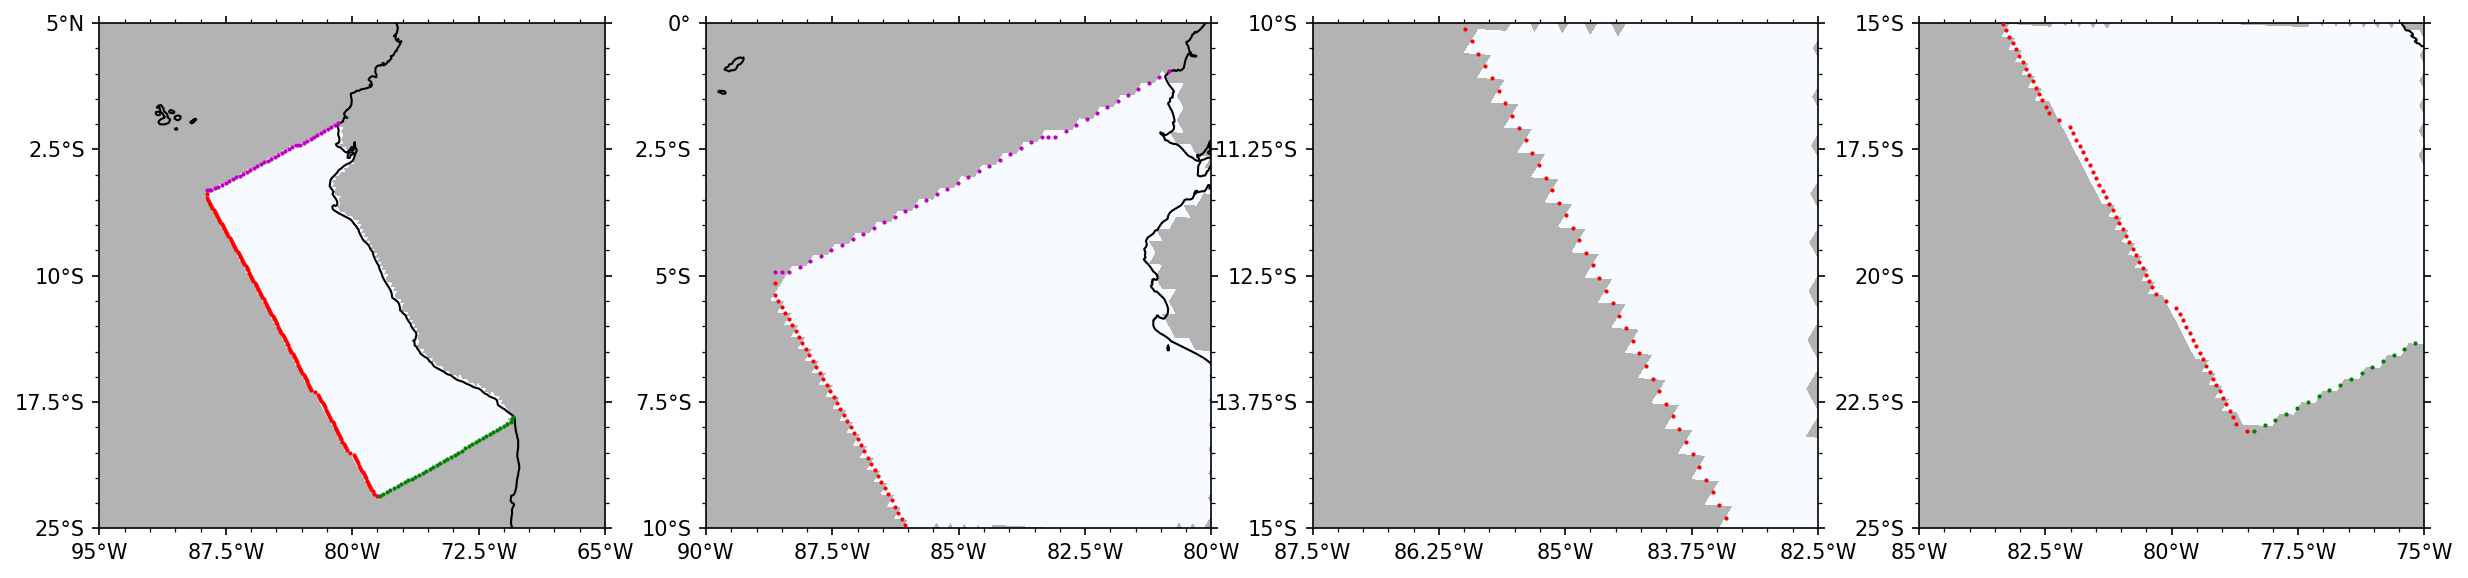

In [13]:
# first convert the section to a edge-based mask
# mask_pc_all_edge, ploy_pc_all = make_section_polygon_mask(ds_sec_pc_all, add_poly=False)
mask_pc_all_edge, ploy_pc_all = make_section_polygon_mask(ds_sec_pc_all, add_poly=False, boundary_buffer=0.12)

# from edge mask to center cell mask
cell_adjacent_to_edge = xr.open_dataset(fpath_tgrid["oce"]).adjacent_cell_of_edge
mask_pc_all_center = edge_to_cell_mask(mask_pc_all_edge, cell_adjacent_to_edge)

mask_pc_all_center = mask_pc_all_center.rename({'cell': 'ncells'})
mask_pc_all_test = mask_pc_all_center.astype("float32")

# check if the mask works
fig, axes = plt.subplots(1,4 ,figsize=(20,5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
axes.flatten()

ax0, hm = mask_pc_all_test.pyic.plot(
    ax=axes[0], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax1, hm = mask_pc_all_test.pyic.plot(
    ax=axes[1], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-90, -80],
    lat_reg=[-10, 0],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax2, hm = mask_pc_all_test.pyic.plot(
    ax=axes[2], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-87.5, -82.5],
    lat_reg=[-15, -10],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax3, hm = mask_pc_all_test.pyic.plot(
    ax=axes[3], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-85, -75],
    lat_reg=[-25, -15],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

for ax in axes:
    ax.scatter(
        sections.elon[sections.mask_pc_all_north_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_north_boundary.compute() !=0],
        c='m', s=1, zorder=3)
    ax.scatter(
        sections.elon[sections.mask_pc_all_west_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_west_boundary.compute() !=0],
        c='r', s=1, zorder=4)
    ax.scatter(
        sections.elon[sections.mask_pc_all_south_boundary.compute() !=0],
        sections.elat[sections.mask_pc_all_south_boundary.compute() !=0],
        c='g', s=1, zorder=5)

plt.show()

## Remove the land boundary point

In [85]:
mask_pc_all_test

<xarray.DataArray (ncells: 935760)> Size: 4MB
array([0., 0., 0., ..., 0., 0., 1.], shape=(935760,), dtype=float32)
Dimensions without coordinates: ncells

In [ ]:
# oce mask -> filter the "land boundary points"
oce_mask_ref = xr.open_dataset(fpath_tgrid["oce"])["cell_sea_land_mask"]
oce_mask_ref = oce_mask_ref.rename({"cell": "ncells"})
# sea (-2 inner, -1 boundary)
oce_mask = (oce_mask_ref == -2) | (oce_mask_ref == -1)

<xarray.DataArray 'cell_sea_land_mask' (ncells: 935760)> Size: 936kB
array([ True,  True,  True, ...,  True,  True,  True], shape=(935760,))
Coordinates:
    clon     (ncells) float64 7MB 1.274 1.282 1.274 1.266 ... 1.337 1.33 1.333
    clat     (ncells) float64 7MB 1.259 1.257 1.261 ... -0.793 -0.7932 -0.7888
Dimensions without coordinates: ncells

In [87]:
mask_pc_all = mask_pc_all_test * oce_mask

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


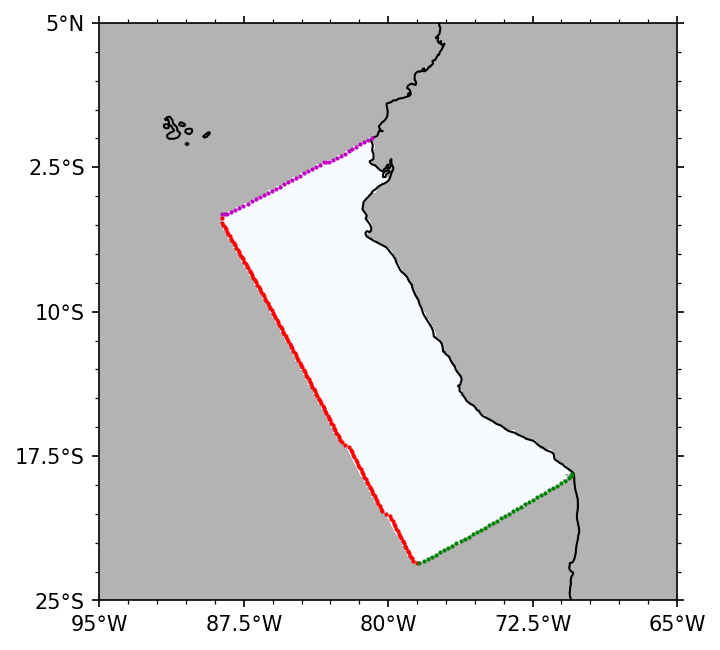

In [88]:
# check if the mask works
fig, ax = plt.subplots(1,1 ,figsize=(5,5), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})

ax2, hm = mask_pc_all.pyic.plot(
    ax=ax, cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax.scatter(
    sections.elon[sections.mask_pc_all_north_boundary.compute() !=0],
    sections.elat[sections.mask_pc_all_north_boundary.compute() !=0],
    c='m', s=1, zorder=3)
ax.scatter(
    sections.elon[sections.mask_pc_all_west_boundary.compute() !=0],
    sections.elat[sections.mask_pc_all_west_boundary.compute() !=0],
    c='r', s=1, zorder=4)
ax.scatter(
    sections.elon[sections.mask_pc_all_south_boundary.compute() !=0],
    sections.elat[sections.mask_pc_all_south_boundary.compute() !=0],
    c='g', s=1, zorder=5)

plt.show()

# 2: Make the 1.0/0.0 Mask based on the sections from 
- The intermediate file to form a region bounded by sections are already finished
    - the script to **generate the region based on sections** can be found at `/home/m/m301254/project_surfwaves/scripts/make_sections_and_bounded_region.ipynb`
    - the output file can be found at `/work/mh0033/m301254/{proj_name}/masks/`

In [105]:
sec_mask = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/peru_coast_sections_masks_oce_r2b7.nc")
sec_mask

<xarray.Dataset> Size: 133kB
Dimensions:           (step_in_path: 322, step_in_path_v: 323, cell: 4678)
Coordinates:
  * step_in_path      (step_in_path) int64 3kB 1 2 3 4 5 ... 318 319 320 321 322
  * cell              (cell) int32 19kB 508209 508210 508211 ... 527762 527763
    elon              (step_in_path) float64 3kB ...
    elat              (step_in_path) float64 3kB ...
    edge              (step_in_path) int32 1kB ...
    vlon              (step_in_path_v) float64 3kB ...
    vlat              (step_in_path_v) float64 3kB ...
    vertex            (step_in_path_v) int32 1kB ...
    clon              (cell) float64 37kB ...
    clat              (cell) float64 37kB ...
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 1kB ...
    vertex_path       (step_in_path_v) int32 1kB ...
    path_orientation  (step_in_path) float64 3kB ...
    contained_cells   (cell) int32 19kB ...
Attributes:
    date:     2026-01-21 17:49:14

In [106]:
tgrid = xr.open_dataset(fpath_tgrid["oce"])
tgrid

<xarray.Dataset> Size: 887MB
Dimensions:                         (cell: 935760, nv: 3, vertex: 475655,
                                     ne: 6, edge: 1411768, no: 4, nc: 2,
                                     max_stored_decompositions: 4, two_grf: 2,
                                     cell_grf: 14, max_chdom: 1, edge_grf: 24,
                                     vert_grf: 13)
Coordinates:
    clon                            (cell) float64 7MB ...
    clat                            (cell) float64 7MB ...
    vlon                            (vertex) float64 4MB ...
    vlat                            (vertex) float64 4MB ...
    elon                            (edge) float64 11MB ...
    elat                            (edge) float64 11MB ...
Dimensions without coordinates: cell, nv, vertex, ne, edge, no, nc,
                                max_stored_decompositions, two_grf, cell_grf,
                                max_chdom, edge_grf, vert_grf
Data variables: (12/91)
    clon_vertices                   (cell, nv) float64 22MB ...
    clat_vertices                   (cell, nv) float64 22MB ...
    vlon_vertices                   (vertex, ne) float64 23MB ...
    vlat_vertices                   (vertex, ne) float64 23MB ...
    elon_vertices                   (edge, no) float64 45MB ...
    elat_vertices                   (edge, no) float64 45MB ...
    ...                              ...
    edge_dual_normal_cartesian_x    (edge) float64 11MB ...
    edge_dual_normal_cartesian_y    (edge) float64 11MB ...
    edge_dual_normal_cartesian_z    (edge) float64 11MB ...
    cell_circumcenter_cartesian_x   (cell) float64 7MB ...
    cell_circumcenter_cartesian_y   (cell) float64 7MB ...
    cell_circumcenter_cartesian_z   (cell) float64 7MB ...
Attributes: (12/34)
    title:                    ICON grid description
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    source:                   Unknown
    revision:                 Unknown
    history:                  /work/mh0287/users/leonidas/icon/GridGenerator_...
    date:                     20191211 at 195212
    ...                       ...
    mean_cell_area:           389176284.94852674
    mean_dual_cell_area:      778350194.560874
    domain_length:            40031612.44147649
    domain_height:            40031612.44147649
    sphere_radius:            6371229.0
    domain_cartesian_center:  [0. 0. 0.]

## Convert `contained_cells`, `edge_path` to full dimension mask ((ncells) and (edge), respectively) 

In [ ]:
# convert the index space to real ncells space
oce_grid = xr.open_dataset(fpath_tgrid["oce"])["cell_area"] # (cell)
mask_bool = oce_grid.cell.isin(sec_mask["contained_cells"])
mask = mask_bool.astype("float32")
mask.name = "pc_all"
mask_rename = mask.rename({'cell': 'ncells'})

In [ ]:
# remove the land boundary points
sea_mask = xr.open_dataset(fpath_tgrid["oce"])["cell_sea_land_mask"].rename({'cell': 'ncells'}) # (ncells)
sea_mask_valid = (sea_mask == -2) | (sea_mask == -1)

mask_corr = mask * sea_mask_valid

In [121]:
mask_corr.name = "pc_all"

In [125]:
ds_mask_oce = xr.Dataset()
ds_mask_oce["pc_all"] = xr.DataArray(
    mask_corr.values,
    dims = mask_corr.dims,
    coords = mask_corr.coords,
    attrs={
        'standard name': 'peru_general_mask',
        'long_name': 'mask for the Peruvian Coast (1) in r2b7 ocean grid',
        'units': '0.0, 1.0',
        'grid_type': 'unstructured'
    }
)

In [127]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask"
ds_mask_oce.to_netcdf(f"{outpath}/mask_pc_all_oce_r2b7.nc")

In [138]:
sec_mask

<xarray.Dataset> Size: 133kB
Dimensions:           (step_in_path: 322, step_in_path_v: 323, cell: 4678)
Coordinates:
  * step_in_path      (step_in_path) int64 3kB 1 2 3 4 5 ... 318 319 320 321 322
  * cell              (cell) int32 19kB 508209 508210 508211 ... 527762 527763
    elon              (step_in_path) float64 3kB -80.83 -80.77 ... -81.24 -81.04
    elat              (step_in_path) float64 3kB -0.9579 -1.078 ... -1.077
    edge              (step_in_path) int32 1kB ...
    vlon              (step_in_path_v) float64 3kB -80.97 -80.7 ... -80.97
    vlat              (step_in_path_v) float64 3kB -0.9573 -0.9585 ... -0.9573
    vertex            (step_in_path_v) int32 1kB ...
    clon              (cell) float64 37kB ...
    clat              (cell) float64 37kB ...
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 1kB 795464 795500 ... 795315 795505
    vertex_path       (step_in_path_v) int32 1kB ...
    path_orientation  (step_in_path) float64 3kB ...
    contained_cells   (cell) int32 19kB ...
Attributes:
    date:     2026-01-21 17:49:14

In [ ]:
mask_bool = tgrid.edge.isin(sec_mask["edge_path"])
mask = mask_bool.astype("float32")
mask

<xarray.DataArray 'edge' ()> Size: 4B
array(1., dtype=float32)

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


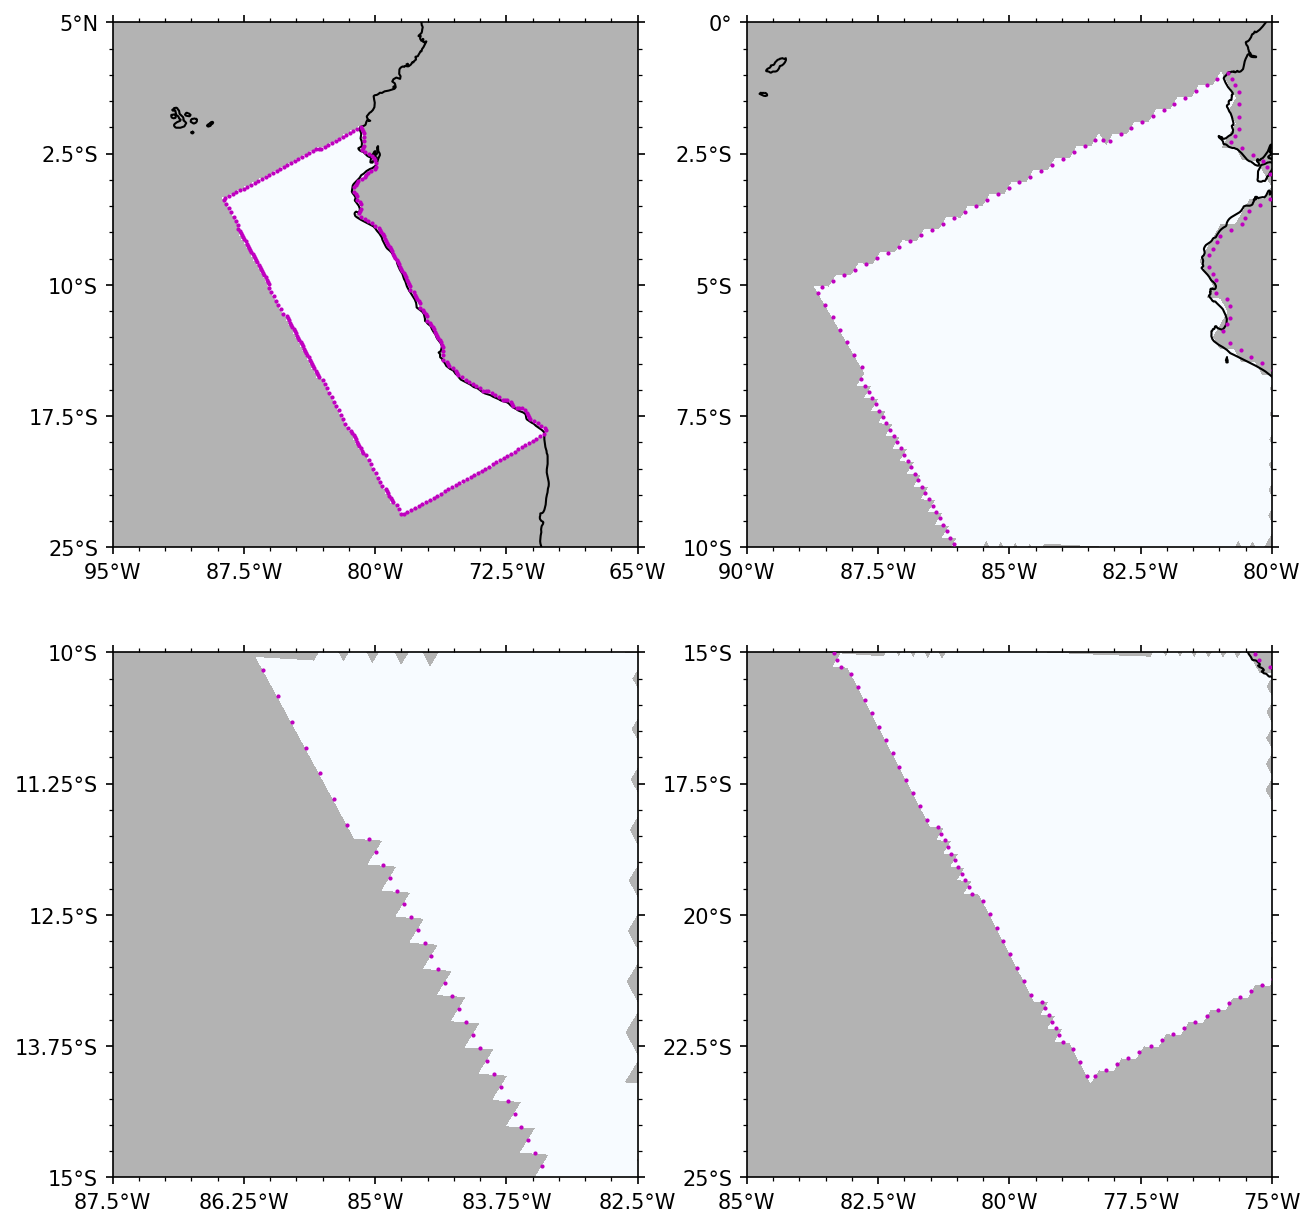

In [145]:
# test if the mask matches with the edge components
fig, axes = plt.subplots(2,2 ,figsize=(10,10), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
# axes.flatten()

ax0, hm = mask_corr.pyic.plot(
    ax=axes[0,0], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax1, hm = mask_corr.pyic.plot(
    ax=axes[0,1], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-90, -80],
    lat_reg=[-10, 0],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax2, hm = mask_corr.pyic.plot(
    ax=axes[1,0], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-87.5, -82.5],
    lat_reg=[-15, -10],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

ax3, hm = mask_corr.pyic.plot(
    ax=axes[1,1], cax=0,
    fpath_tgrid=fpath_tgrid['oce'],
    fpath_ckdtree=fpath_ckdtree['oce'],
    lon_reg=[-85, -75],
    lat_reg=[-25, -15],
    plot_method='tgrid',
    cmap="Blues",
    land_facecolor='none',
)

for ax in axes.ravel():
    ax.scatter(
        np.degrees(tgrid.elon[mask == 1]),
        np.degrees(tgrid.elat[mask == 1]),
        c='m', s=1, zorder=5
    )
plt.show()

# 3.1 Wrap-up (suitable for lower-to-intermediate data)
- Save the converted regional mask (cell-based, shape: (ncells)) and the corresponding 4 boundaries (edge-based, shape (edge)) together in a single NetCDF file.
- For *lower-to-intermediate* resolutions, this converted version is more direct and advantageous for plotting and visualization.
- However, for **regional-mean analyses**, the converted mask is **less efficient** than using the original outputs from `make_sections_and_bounded_region.ipynb`, since the original workflow pre-selects cells within the region and ignores outside cells from the outset.
    - The **original outputs may therefore be preferable when working with higher-resolution datasets** (e.g., r2b9), where computational efficiency becomes more important. However, a certain wrap-up is still needed and is listed in section **3.2**

### Function: plot for check the match between cell mask and edge mask

In [9]:
def plot_cellmask_secmask_compare(ds_masks, cellmask_name, which_bd, fpath_tgrid, fpath_ckdtree,):
    """
    Plot mask fields and overlay edge orientations for a selected boundary.

    Parameters
    ----------
    ds_masks : dict
        Dictionary containing mask fields (cell mask + boundary masks).
    cellmask_name : str
        Key in pc_all_masks for the cell mask
    which_bd : str
        Key in pc_all_masks for the boundary mask
    fpath_tgrid : dict
        Dictionary with tgrid file paths (expects key 'oce').
    fpath_ckdtree : dict
        Dictionary with ckdtree file paths (expects key 'oce').
    """
    # test if the mask matches with the edge components
    tgrid = xr.open_dataset(fpath_tgrid["oce"])
    fig, axes = plt.subplots(2,2 ,figsize=(6,6), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
    # axes.flatten()

    plot_kwargs = dict(cax=0,
                       fpath_tgrid=fpath_tgrid["oce"],
                       fpath_ckdtree=fpath_ckdtree["oce"],
                       plot_method="tgrid",
                       cmap="Blues",
                       land_facecolor="none",)

    ax0, hm = ds_masks[cellmask_name].pyic.plot(
        ax=axes[0,0], 
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        **plot_kwargs,
    )

    ax1, hm = ds_masks[cellmask_name].pyic.plot(
        ax=axes[0,1],
        lon_reg=[-90, -80],
        lat_reg=[-10, 0],
        **plot_kwargs,
    )

    ax2, hm = ds_masks[cellmask_name].pyic.plot(
        ax=axes[1,0],
        lon_reg=[-87.5, -82.5],
        lat_reg=[-15, -10],
        **plot_kwargs,
    )

    ax3, hm = ds_masks[cellmask_name].pyic.plot(
        ax=axes[1,1],
        lon_reg=[-85, -75],
        lat_reg=[-25, -15],
        **plot_kwargs,
    )

    for ax in axes.ravel():
        ax.scatter(
            np.degrees(tgrid.elon[ds_masks[f"{which_bd}_boundary"] == 1]),
            np.degrees(tgrid.elat[ds_masks[f"{which_bd}_boundary"] == 1]),
            c='m', s=1, zorder=5
        )
        ax.scatter(
            np.degrees(tgrid.elon[ds_masks[f"{which_bd}_boundary"] == -1]),
            np.degrees(tgrid.elat[ds_masks[f"{which_bd}_boundary"] == -1]),
            c='b', s=1, zorder=5
        )
    plt.show()

### Function: wrap up into dataset

In [5]:
def build_cellmask_sectionmask_to_dataset(region_name, fpath_dir, grid_info, fpath_tgrid,):
    """
    Build a dataset containing:
      1) A cell mask (ncells) defining the interior of a region
      2) Signed edge masks (edge) defining the region boundaries

    Cell mask:
        - Dimension: ncells
        - Values: 0.0 (outside), 1.0 (inside)
        - Land cells are removed

    Edge masks:
        - Dimension: edge
        - Values:
            0   → not part of the boundary
           -1/+1 → boundary edge with orientation

    Parameters
    ----------
    region_name : str
        Name of the region (e.g. "pc_all").
    fpath_dir : str
        Directory containing section mask NetCDF files.
    grid_info : str
        Grid identifier (e.g. "oce_r2b7").
    fpath_tgrid : str
        Path to ICON ocean tgrid file.

    Returns
    -------
    ds : xr.Dataset
        Dataset containing:
        - {region_name}                    (ncells)
        - {region_name}_north_boundary     (edge)
        - {region_name}_south_boundary     (edge)
        - {region_name}_east_boundary      (edge)
        - {region_name}_west_boundary      (edge)
    """
    # read file
    sec_mask = xr.open_dataset(f"{fpath_dir}{region_name}_sections_masks_{grid_info}.nc")
    sec_north = xr.open_dataset(f"{fpath_dir}{region_name}_sections_NorthBoundarySection_{grid_info}.nc")
    sec_west = xr.open_dataset(f"{fpath_dir}{region_name}_sections_WestBoundarySection_{grid_info}.nc")
    sec_south = xr.open_dataset(f"{fpath_dir}{region_name}_sections_SouthBoundarySection_{grid_info}.nc")
    sec_east = xr.open_dataset(f"{fpath_dir}{region_name}_sections_EastBoundarySection_{grid_info}.nc")
    tgrid = xr.open_dataset(fpath_tgrid)
    ds = xr.Dataset()

    # Cell mask (ncells)
    mask_bool = tgrid.cell.isin(sec_mask["contained_cells"])
    mask = mask_bool.astype("float32").rename({"cell": "ncells"})
    # Remove land cells
    sea_mask = tgrid["cell_sea_land_mask"].rename({"cell": "ncells"})
    sea_mask_valid = (sea_mask == -2) | (sea_mask == -1)
    mask_corr = mask * sea_mask_valid

    ds[region_name] = xr.DataArray(
        mask_corr.data,
        dims=mask_corr.dims,
        coords=mask_corr.coords,
        attrs={
            "standard_name": f"{region_name}_mask",
            "long_name": f"Cell mask for {region_name} region",
            "units": "0.0, 1.0",
            "grid_type": "unstructured",
        },
    )

    # Signed edge masks
    boundaries = [
        (f"north_boundary", sec_north),
        (f"south_boundary", sec_south),
        (f"east_boundary",  sec_east),
        (f"west_boundary",  sec_west),
    ]

    for boundary_name, sec in boundaries:
        edge_orientation = xr.zeros_like(tgrid["edge"], dtype="float64")
        edge_orientation.loc[dict(edge=sec["edge_path"])] = sec["path_orientation"]
        ds[boundary_name] = xr.DataArray(
            edge_orientation.data,
            dims=edge_orientation.dims,
            coords=edge_orientation.coords,
            attrs={
                "standard_name": boundary_name,
                "long_name": f"{boundary_name} edge mask (with direction) for {region_name}",
                "units": "degrees (-1.0, 1.0)",
                "grid_type": "unstructured",
            },
        )

        # edge index
        ie = xr.full_like(tgrid["edge"], fill_value=-1, dtype="int32")
        ie.loc[dict(edge=sec["edge_path"])]=sec["edge_path"]
        ds[f"ie_{boundary_name}"] = xr.DataArray(
            ie,
            dims=ie.dims,
            coords=ie.coords,
            attrs={
                "long_name": f"{boundary_name} valid edge index for {region_name} region",
                "values": "-1 (not in section), index (in section)",
                "grid_type": "unstructured",
            },
        )

        # vertex index
        iv = xr.full_like(tgrid["vertex"], fill_value=-1, dtype="int32")
        iv.loc[dict(vertex=sec["vertex_path"])] = sec["vertex_path"]
        ds[f"iv_{boundary_name}"] = xr.DataArray(
            iv,
            dims=iv.dims,
            coords=iv.coords,
            attrs={
                "long_name": f"{boundary_name} valid vertex index for {region_name} region",
                "values": "-1 (not in section), index (in section)",
                "grid_type": "unstructured",
            },
        )
        
    sec_mask.close()
    sec_north.close()
    sec_south.close()
    sec_east.close()
    sec_west.close()
    tgrid.close()

    return ds

In [14]:
# base
fpath_dir = "/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/"
grid_info = "oce_r2b7"

# pc_all: general peru coastal region
region_name = "pc_all"
pc_all_masks =  build_cellmask_sectionmask_to_dataset(region_name, fpath_dir, grid_info, fpath_tgrid["oce"])

# pc_middle: focusing on the almost-parallel band
region_name = "pc_middle"
pc_middle_masks =  build_cellmask_sectionmask_to_dataset(region_name, fpath_dir, grid_info, fpath_tgrid["oce"])

# pc_north: northern component of the pc_all
region_name = "pc_north"
pc_north_masks =  build_cellmask_sectionmask_to_dataset(region_name, fpath_dir, grid_info, fpath_tgrid["oce"])

# pc_south: southern component of the pc_all
region_name = "pc_south"
pc_south_masks =  build_cellmask_sectionmask_to_dataset(region_name, fpath_dir, grid_info, fpath_tgrid["oce"])

In [13]:
# check if the index for edge and vertex works
b = "west_boundary"
n_ie = (pc_all_masks[f"ie_{b}"] >= 0).sum().item()
n_sec = pc_all_masks[f"{b}"].where(pc_all_masks[f"{b}"] != 0, drop=True).edge.size
n_iv = (pc_all_masks[f"iv_{b}"] >= 0).sum().item()

print(n_ie, n_sec, n_iv)

# print(n_iv, len(sec_north["vertex_path"]))

111 111 112


Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


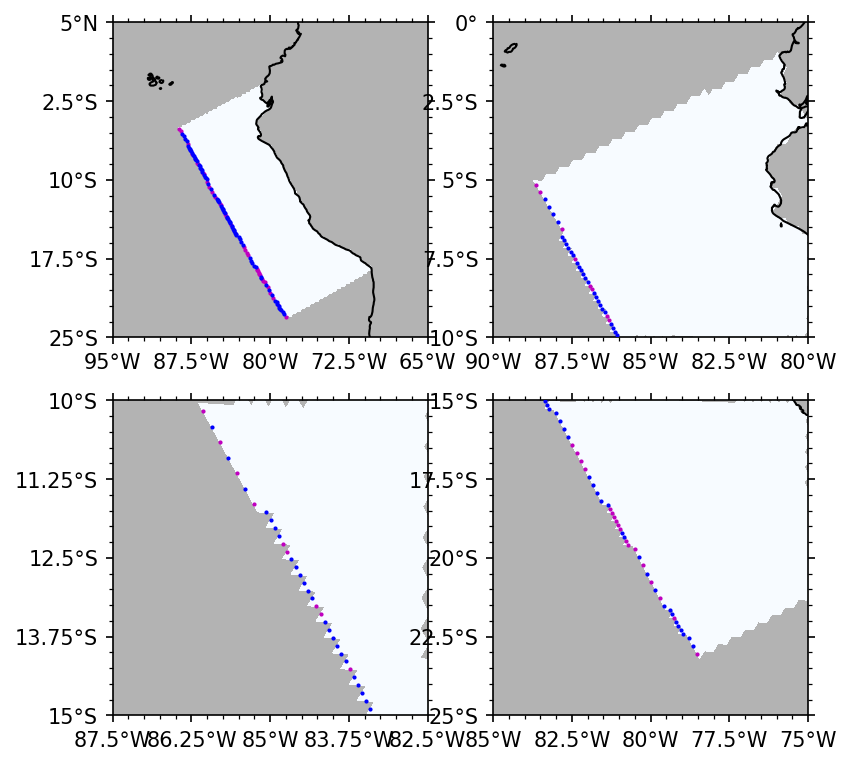

In [10]:
# check if the ds_masks are correct
plot_cellmask_secmask_compare(pc_all_masks, "pc_all", "west", fpath_tgrid, fpath_ckdtree,)
# plot_cellmask_secmask_compare(pc_north_masks, "pc_north", "north", fpath_tgrid, fpath_ckdtree,)

In [15]:
# save
outpath = "/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask"
pc_all_masks.to_netcdf(f"{outpath}/full_masks_pc_all_oce_r2b7.nc")
pc_middle_masks.to_netcdf(f"{outpath}/full_masks_pc_middle_oce_r2b7.nc")
pc_north_masks.to_netcdf(f"{outpath}/full_masks_pc_north_oce_r2b7.nc")
pc_south_masks.to_netcdf(f"{outpath}/full_masks_pc_south_oce_r2b7.nc")

# 3.2: Wrap-up the individual sections

In [10]:
# read file
fpath_dir = "/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/"
sec1 = xr.open_dataset(f"{fpath_dir}section1_r2b9.nc")
sec2 = xr.open_dataset(f"{fpath_dir}section2_r2b9.nc")
sec3 = xr.open_dataset(f"{fpath_dir}section3_r2b9.nc")
sec4 = xr.open_dataset(f"{fpath_dir}section4_r2b9.nc")
sec5 = xr.open_dataset(f"{fpath_dir}section5_r2b9.nc")

In [11]:
sec1

<xarray.Dataset> Size: 7kB
Dimensions:           (step_in_path: 119, step_in_path_v: 120)
Coordinates:
  * step_in_path      (step_in_path) int32 476B 4195968 4195963 ... 4149169
  * step_in_path_v    (step_in_path_v) int32 480B 4195956 4195968 ... 4149169
    elon              (step_in_path) float64 952B ...
    elat              (step_in_path) float64 952B ...
    edge              (step_in_path) int32 476B ...
    vlon              (step_in_path_v) float64 960B ...
    vlat              (step_in_path_v) float64 960B ...
Data variables:
    edge_path         (step_in_path) int32 476B ...
    vertex_path       (step_in_path_v) int32 480B ...
    path_orientation  (step_in_path) float64 952B ...
Attributes:
    date:     2026-01-23 16:58:38

In [30]:
tgrid = xr.open_dataset(fpath_tgrid["oce"])
ds_secs_all = xr.Dataset()

# Signed edge masks
secs = [
        (f"section1", sec1),
        (f"section2", sec2),
        (f"section3", sec3),
        (f"section4", sec4),
        (f"section5", sec5),
    ]

for sec_name, sec in secs:
    # edge orientation
    edge_orientation = xr.zeros_like(tgrid["edge"], dtype="float64")
    edge_orientation.loc[dict(edge=sec["edge_path"])] = sec["path_orientation"]
    ds_secs_all[sec_name] = xr.DataArray(
        edge_orientation.data,
        dims=edge_orientation.dims,
        coords=edge_orientation.coords,
        attrs={"standard_name": sec_name,
               "long_name": f"boundary edge mask (with direction) for {region_name}",
               "units": "degrees (-1.0, 1.0)",
               "grid_type": "unstructured",
            },
    )

    # edge index
    ie = xr.full_like(tgrid["edge"], fill_value=-1, dtype="int32")
    ie.loc[dict(edge=sec["edge_path"])]=sec["edge_path"]
    ds_secs_all[f"ie_{sec_name}"] = xr.DataArray(
        ie,
        dims=ie.dims,
        coords=ie.coords,
        attrs={
            "long_name": f"{sec_name} valid edge index",
            "values": "0 (not in section), index (in section)",
            "grid_type": "unstructured",
        },
    )

    # vertex index
    iv = xr.full_like(tgrid["vertex"], fill_value=-1, dtype="int32")
    iv.loc[dict(vertex=sec["vertex_path"])] = sec["vertex_path"]
    ds_secs_all[f"iv_{sec_name}"] = xr.DataArray(
        iv,
        dims=iv.dims,
        coords=iv.coords,
        attrs={
            "long_name": f"{sec_name} valid vertex index",
            "values": "0 (not in section), index (in section)",
            "grid_type": "unstructured",
        },
    )

In [35]:
outpath = fpath_dir
ds_secs_all.to_netcdf(f"{outpath}all_sections_r2b9_FraserVersion.nc")

# 4: Crop the tgrid to a region based on the regional mask
- using the mask to generate the specific tgrid file for the seleted cells
- the specific tgrid file can be extremely helpful when you trying to do regional analysis using built-in functions in `pyicon`

## Function: crop tgrid accoriding to mask

In [ ]:
def crop_tgrid_to_region(tgrid, mask):
    """Crop tgrid to the region defined by the mask.

    Parameters
    ----------
    tgrid : xarray.Dataset
        The tgrid dataset.
    mask : xarray.DataArray
        The mask defining the region to crop to.

    Returns
    -------
    xarray.Dataset
        The cropped tgrid dataset.
    """
    ireg_c = mask["contained_cells"].astype(int)
    crop_tg = pyic.xr_crop_tgrid(tgrid, ireg_c)
    return crop_tg

## r2b7

In [16]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}
# info for the grids
gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'
# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'
# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')
fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

In [ ]:
# tgrid info
tgrid = xr.open_dataset(fpath_tgrid["oce"])
# masks
mask_pc_all = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_all_sections_masks_oce_r2b7.nc")
mask_pc_middle = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_middle_sections_masks_oce_r2b7.nc")
mask_pc_north = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_north_sections_masks_oce_r2b7.nc")
mask_pc_south = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_masks_oce_r2b7.nc")

# crop the corresponding tgrid file
print("cropping the tgrid:")
crop_tg_pc_all = crop_tgrid_to_region(tgrid, mask_pc_all)
crop_tg_pc_middle = crop_tgrid_to_region(tgrid, mask_pc_middle)
crop_tg_pc_north = crop_tgrid_to_region(tgrid, mask_pc_north)
crop_tg_pc_south = crop_tgrid_to_region(tgrid, mask_pc_south)

# save
outpath = "/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/"
crop_tg_pc_all.to_netcdf(f"{outpath}pc_all_mask_cropped_tgrid_oce_r2b7.nc")
crop_tg_pc_middle.to_netcdf(f"{outpath}pc_middle_mask_cropped_tgrid_oce_r2b7.nc")
crop_tg_pc_north.to_netcdf(f"{outpath}pc_north_mask_cropped_tgrid_oce_r2b7.nc")
crop_tg_pc_south.to_netcdf(f"{outpath}pc_south_mask_cropped_tgrid_oce_r2b7.nc")

In [ ]:
# example usage
crop_tg_test = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_all_mask_cropped_tgrid_oce_r2b7.nc")
# transfer to ICON readable dataset
ds_IcD = pyic.convert_tgrid_data(crop_tg_test)
print("cropped tgrid has been created.")
# Optional: keep selected ncells index (still 0-based)
ncells_selected = crop_tg_test.cell.rename({"cell": "ncells"})
zeros = xr.zeros_like(tgrid["cell_area"], dtype="float64")
zeros.loc[dict(cell=ncells_selected.rename({"ncells": "cell"}))] = 1.0

# check the mask 
zeros.pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    plot_method="tgrid",
    cmap="Blues",
    land_facecolor="none",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    clim=[0, 1],
)

## r2b9

In [ ]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b9_oce_r0004'
gname_atm = 'r2b8_atm_r0033'
lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b8_atm_r0033_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b9_oce_r0004_res0.30_180W-180E_90S-90N.nc')

In [ ]:
# tgrid info
tgrid = xr.open_dataset(fpath_tgrid["oce"])
# mask
mask_pc_middle = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_masks_oce_r2b9.nc")
# crop tgrid
print("cropping the tgrid:")
crop_tg = crop_tgrid_to_region(tgrid, mask_pc_middle)
outpath = "/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/"
crop_tg.to_netcdf(f"{outpath}pc_middle_mask_cropped_tgrid_oce_r2b9.nc")

# # Convert cropped tgrid to ICON-ready datasets
# ds_IcD = pyic.convert_tgrid_data(crop_tg)
# print("cropped tgrid has been created.")
# # Optional: keep selected ncells index (still 0-based)
# ncells_selected = crop_tg.cell.rename({"cell": "ncells"})

# 5: Mask the adjacent cells to the given section (edge_mask)

In [3]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}
# info for the grids
gname_oce = 'r2b9_oce_r0004'
gname_atm = 'r2b8_atm_r0033'
lev_oce = 'L72'
# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')
fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b8_atm_r0033_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b9_oce_r0004_res0.30_180W-180E_90S-90N.nc')

In [4]:
# use the ["adjacent_cell_of_edge"] in the tgrid file
tgrid = xr.open_dataset(fpath_tgrid["oce"])

In [5]:
tgrid

<xarray.Dataset> Size: 14GB
Dimensions:                         (cell: 14886338, nv: 3, vertex: 7487687,
                                     ne: 6, edge: 22375924, no: 4, nc: 2,
                                     max_stored_decompositions: 4, two_grf: 2,
                                     cell_grf: 14, max_chdom: 1, edge_grf: 24,
                                     vert_grf: 13)
Coordinates:
    clon                            (cell) float64 119MB ...
    clat                            (cell) float64 119MB ...
    vlon                            (vertex) float64 60MB ...
    vlat                            (vertex) float64 60MB ...
    elon                            (edge) float64 179MB ...
    elat                            (edge) float64 179MB ...
Dimensions without coordinates: cell, nv, vertex, ne, edge, no, nc,
                                max_stored_decompositions, two_grf, cell_grf,
                                max_chdom, edge_grf, vert_grf
Data variables: (12/91)
    clon_vertices                   (cell, nv) float64 357MB ...
    clat_vertices                   (cell, nv) float64 357MB ...
    vlon_vertices                   (vertex, ne) float64 359MB ...
    vlat_vertices                   (vertex, ne) float64 359MB ...
    elon_vertices                   (edge, no) float64 716MB ...
    elat_vertices                   (edge, no) float64 716MB ...
    ...                              ...
    edge_dual_normal_cartesian_x    (edge) float64 179MB ...
    edge_dual_normal_cartesian_y    (edge) float64 179MB ...
    edge_dual_normal_cartesian_z    (edge) float64 179MB ...
    cell_circumcenter_cartesian_x   (cell) float64 119MB ...
    cell_circumcenter_cartesian_y   (cell) float64 119MB ...
    cell_circumcenter_cartesian_z   (cell) float64 119MB ...
Attributes: (12/34)
    title:                    ICON grid description
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    source:                   Unknown
    revision:                 Unknown
    history:                  /work/mh0287/users/leonidas/icon/GridGenerator_...
    date:                     20180226 at 160532
    ...                       ...
    mean_cell_area:           24323517.809282698
    mean_dual_cell_area:      48647026.33989711
    domain_length:            40031612.44147649
    domain_height:            40031612.44147649
    sphere_radius:            6371229.0
    domain_cartesian_center:  [0. 0. 0.]

In [6]:
sections = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/all_sections_r2b9_NilsVersion.nc")

In [7]:
sections

<xarray.Dataset> Size: 1GB
Dimensions:        (edge: 22375924, vertex: 7487687)
Dimensions without coordinates: edge, vertex
Data variables: (12/19)
    elon           (edge) float32 90MB ...
    elat           (edge) float32 90MB ...
    vlon           (vertex) float32 30MB ...
    vlat           (vertex) float32 30MB ...
    mask_section1  (edge) int32 90MB ...
    ie_section1    (edge) int32 90MB ...
    ...             ...
    mask_section4  (edge) int32 90MB ...
    ie_section4    (edge) int32 90MB ...
    iv_section4    (vertex) int32 30MB ...
    mask_section5  (edge) int32 90MB ...
    ie_section5    (edge) int32 90MB ...
    iv_section5    (vertex) int32 30MB ...

/tmp/ipykernel_3339050/1171783346.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tgrid.dims["cell"] - 1,


cell min/max: 8222315 8333106  expected: 0 … 14886337
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7ff0a4931150>])

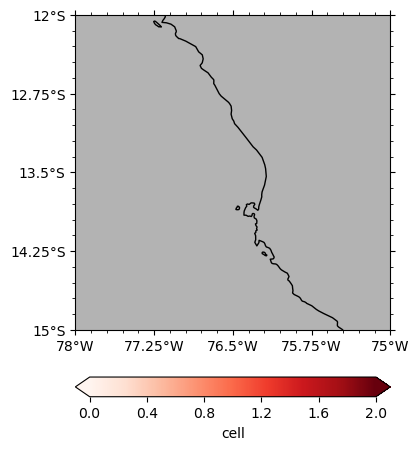

In [ ]:
valid_ie_1 = sections.ie_section1.where(sections.ie_section1 >= 0, drop=True)
edges_sec1 = valid_ie_1.values.astype("int32")

# convert adjacent_cell_of_edge to 0-based indexing
# (ICON: 0 = invalid, 1..ncell = valid)
adj0 = xr.where(
    tgrid.adjacent_cell_of_edge > 0,
    tgrid.adjacent_cell_of_edge - 1,
    -1,
)

# select adjacent cells of the section edges
adj_cells_sec1 = adj0.sel(edge=edges_sec1)

# flatten, remove invalid cells, unique
cells_sec1 = adj_cells_sec1.values.ravel()
cells_sec1 = cells_sec1[cells_sec1 > 0]
cells_sec1 = np.unique(cells_sec1)

# cell mask
cell_mask_sec1 = tgrid.cell.isin(cells_sec1).astype("float32")

# quick sanity check (recommended)
print(
    "cell min/max:",
    cells_sec1.min(),
    cells_sec1.max(),
    " expected: 0 …",
    tgrid.dims["cell"] - 1,
)

cell_mask_sec1.pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"], 
    fpath_ckdtree=fpath_ckdtree["oce"], 
    plot_method="tgrid", 
    cmap="Reds", 
    land_facecolor="none", 
    lon_reg=[-87.5, -75], 
    lat_reg=[-18, -2.5], 
    # lon_reg=[-78, -75], 
    # lat_reg=[-15, -12], 
    clim=[0, 2], 
)

In [9]:
# 0. Load tgrid + sections
tgrid = xr.open_dataset(fpath_tgrid["oce"])
sections = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/all_sections_r2b9_NilsVersion.nc")

# Find all section variables
sec_vars = [v for v in sections.data_vars if v.startswith("ie_section")]

# Function: make cell mask from edge indices
def make_cell_mask_from_edges(ie_edges):
    edges = ie_edges.where(ie_edges >= 0, drop=True).values.astype("int32")

    adj0 = xr.where(
        tgrid.adjacent_cell_of_edge > 0,
        tgrid.adjacent_cell_of_edge - 1,
        -1,
    )

    adj_cells = adj0.sel(edge=edges)
    cells = adj_cells.values.ravel()
    cells = cells[cells > 0]
    cells = np.unique(cells)

    cell_mask = tgrid.cell.isin(cells).astype("int")
    return cell_mask, cells

# Loop over sections: create masks + cell indices
data_vars = {}

for var in sec_vars:
    sec_name = var.replace("ie_", "")
    # create mask and cell index
    cell_mask, cell_idx = make_cell_mask_from_edges(sections[var])

    # store mask
    data_vars[f"mask_{sec_name}"] = cell_mask

    # store cell indices with unique dimension
    dim_name = f"cells_{sec_name}"
    data_vars[f"cells_{sec_name}"] = xr.DataArray(
        cell_idx,
        dims=[dim_name],
        name=f"cells_{sec_name}",
    )

# Build one dataset
ds_all = xr.Dataset(data_vars)


In [10]:
ds_all

<xarray.Dataset> Size: 834MB
Dimensions:         (cell: 14886338, cells_section1: 236, cells_section2: 238,
                     cells_section3: 234, cells_section4: 230,
                     cells_section5: 234)
Coordinates:
  * cells_section1  (cells_section1) int32 944B 8222315 8222316 ... 8333106
  * cells_section2  (cells_section2) int32 952B 8263370 8263379 ... 8333570
  * cells_section3  (cells_section3) int32 936B 8260167 8260168 ... 8329219
  * cells_section4  (cells_section4) int32 920B 8268397 8268421 ... 8328971
  * cells_section5  (cells_section5) int32 936B 8072275 8072276 ... 8328250
    clon            (cell) float64 119MB 1.274 1.276 1.274 ... 1.335 1.336 1.334
    clat            (cell) float64 119MB 1.259 1.259 1.26 ... -0.7894 -0.7895
Dimensions without coordinates: cell
Data variables:
    mask_section1   (cell) int64 119MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    mask_section2   (cell) int64 119MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    mask_section3   (cell) int64 119MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    mask_section4   (cell) int64 119MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    mask_section5   (cell) int64 119MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

In [85]:
# 5. Save
out_path = "/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/"
ds_all.to_netcdf(f"{out_path}all_sections_adjacent_cells_masks-indexes_r2b9_NilsVersion.nc")


In [11]:
cell_area = tgrid["cell_area"].sel(cell=ds_all.cells_section1.rename({"cells_section1": "cell"}))

In [12]:
cell_area

<xarray.DataArray 'cell_area' (cell: 236)> Size: 2kB
[236 values with dtype=float64]
Coordinates:
    clon     (cell) float64 2kB ...
    clat     (cell) float64 2kB ...
Dimensions without coordinates: cell
Attributes:
    long_name:                    area of grid cell
    units:                        m2
    standard_name:                area
    grid_type:                    unstructured
    number_of_grid_in_reference:  1